In [ ]:
import pytensor
import warnings
import numba
pytensor.config.mode = "NUMBA"
warnings.filterwarnings("ignore", category=numba.NumbaPerformanceWarning)
import numpy as np

import pymc as pm
import arviz as az

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
y = np.array([28, 8, -3, 7, -1, 1, 18, 12])
sigma = np.array([15, 10, 16, 11, 9, 11, 10, 18])

In [3]:
with pm.Model() as pooled:
    theta = pm.Normal("theta", 0, sigma=1e6)
    obs = pm.Normal("obs", theta, sigma=sigma, observed=y)
    trace_p = pm.sample(random_state=0)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.


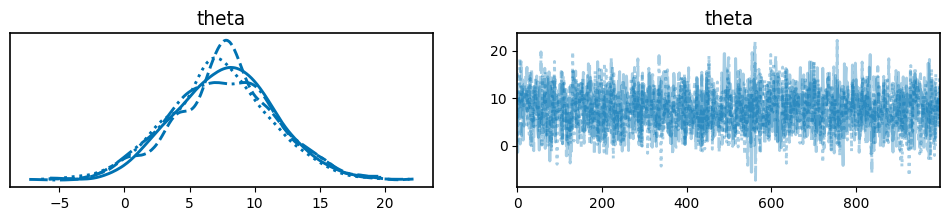

In [4]:
az.plot_trace(trace_p)
plt.show()

In [5]:
trace_p.posterior["theta"].values.mean()

7.574385620185722

In [6]:
with pm.Model() as hierarchical:
    mu = pm.Normal("mu", 0, sigma=100)
    tau = pm.HalfNormal("tau", 100)
    theta = pm.Normal("theta", mu=mu, sigma=tau, shape=len(y))
    
    obs = pm.Normal("obs", theta, sigma=sigma, observed=y)

    trace_h = pm.sample(draws=10_000, target_accept=0.9, random_state=0)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, tau, theta]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 24 seconds.
There were 1456 divergences after tuning. Increase `target_accept` or reparameterize.


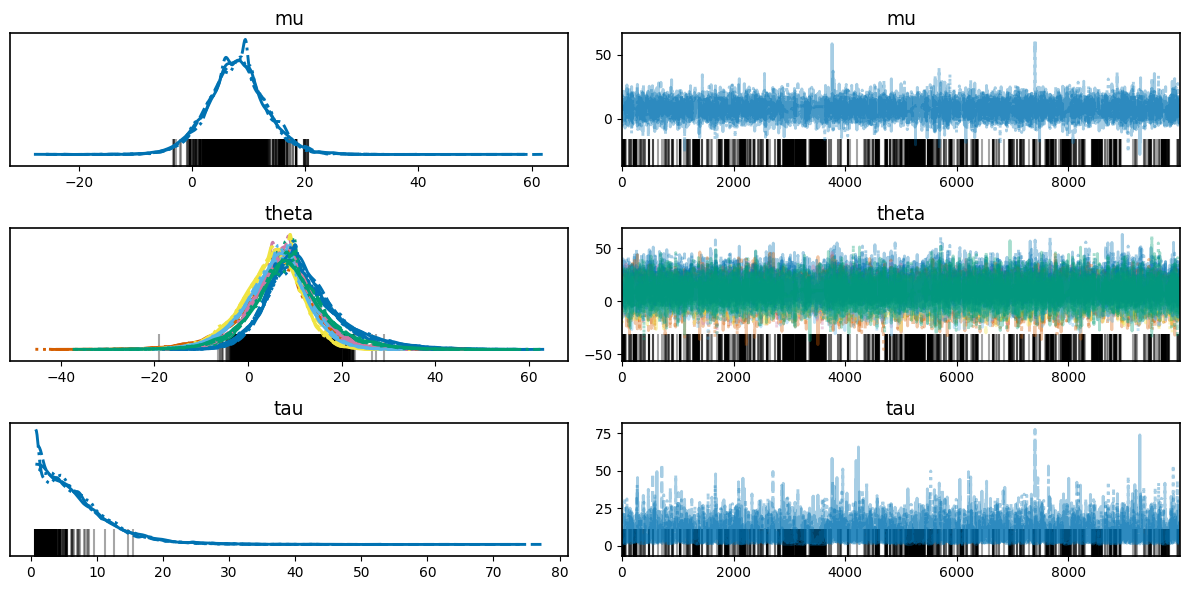

In [7]:
az.plot_trace(trace_h)
plt.tight_layout()
plt.show()

In [8]:
(
    (trace_h.posterior["tau"].values > 25).mean(),
    (trace_h.posterior["tau"].values < 10).mean(),
)

(0.0118, 0.768225)

In [5]:
tau_bins = np.linspace(0, 20, 11)
tau_bin_indices = np.digitize(trace_h.posterior["tau"], bins=tau_bins)
# tau_bin_indices

In [6]:
theta_means = np.zeros((len(tau_bins), len(y)))
theta_stddevs = np.zeros((len(tau_bins), len(y)))

for i in range(len(tau_bins)):
    theta_given_tau = (
        trace_h
        .posterior
        ["theta"]
        .values
        [tau_bin_indices == i + 1]
    )

    theta_means[i, :] = theta_given_tau.mean(axis=0)
    theta_stddevs[i, :] = theta_given_tau.std(axis=0)

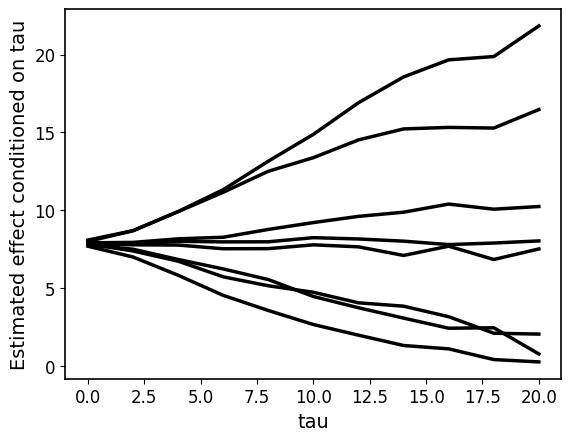

In [16]:
for j in range(len(y)):
    plt.plot(
        tau_bins,
        theta_means[:, j],
        # yerr=theta_stddevs[:, j],
        # label=f"School number {j + 1}",
        # fmt="o-",
        # cmap="Set1",
        color="k",
    )

plt.xlabel("tau")
plt.ylabel("Estimated effect conditioned on tau")

plt.show()

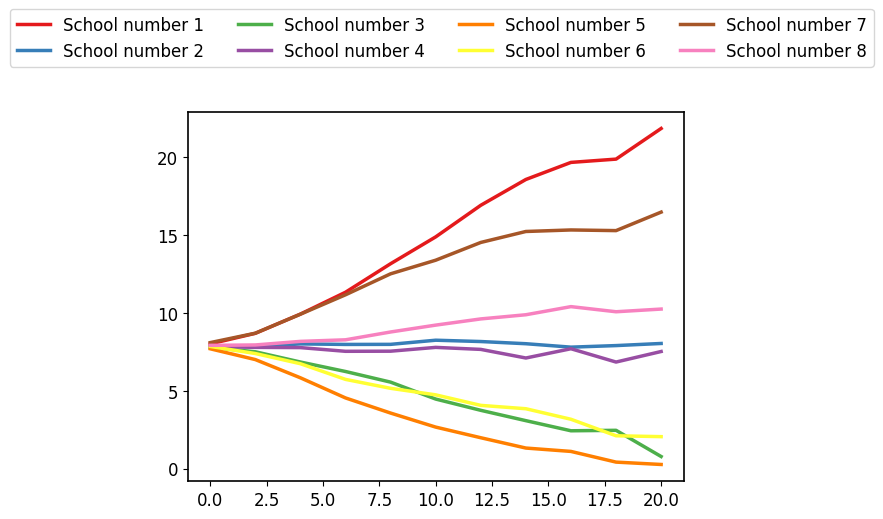

In [12]:
with sns.color_palette("Set1", n_colors=8):
    for j in range(len(y)):
        plt.plot(
            tau_bins,
            theta_means[:, j],
            # yerr=theta_stddevs[:, j],
            label=f"School number {j + 1}",
            # fmt="o-",
            # cmap="Set1",
        )

plt.legend(ncol=4, bbox_to_anchor=(1.4, 1.3))
plt.show()

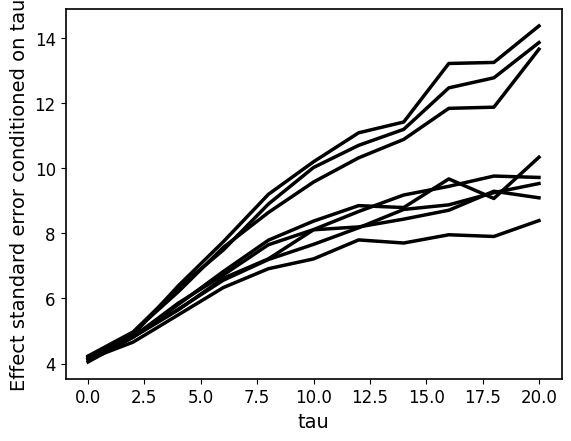

In [31]:
for j in range(len(y)):
    plt.plot(
        tau_bins,
        theta_stddevs[:, j],
        # yerr=theta_stddevs[:, j],
        label=f"School number {j + 1}",
        # fmt="o-",
        # cmap="Set1",
        color="k",
    )

plt.xlabel("tau")
plt.ylabel("Effect standard error conditioned on tau")
plt.show()

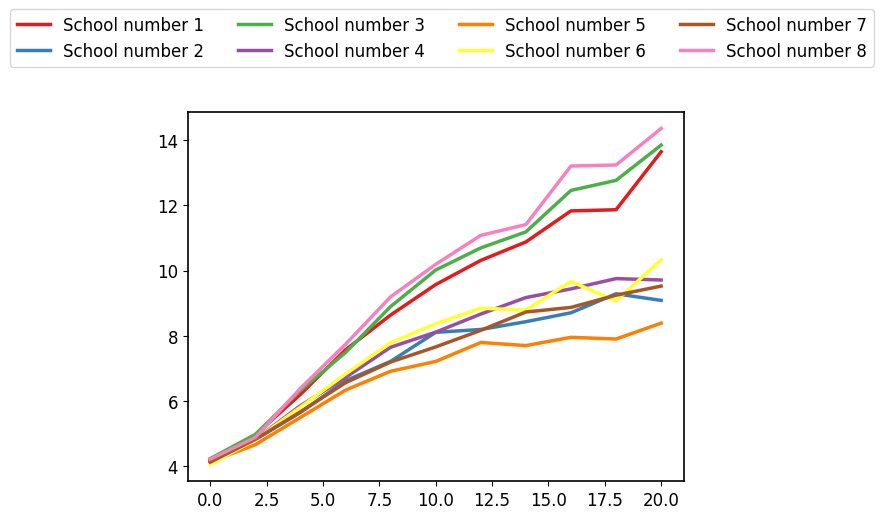

In [29]:
with sns.color_palette("Set1", n_colors=8):
    for j in range(len(y)):
        plt.plot(
            tau_bins,
            theta_stddevs[:, j],
            # yerr=theta_stddevs[:, j],
            label=f"School number {j + 1}",
            # fmt="o-",
            # cmap="Set1",
        )

plt.legend(ncol=4, bbox_to_anchor=(1.4, 1.3))
plt.show()

In [9]:
post_thetas = trace_h.posterior["theta"].values

In [24]:
for i in range(8):
    print(i, (post_thetas.argmax(axis=-1) == i).mean())

0 0.26315
1 0.0993
2 0.080625
3 0.09465
4 0.0463
5 0.068575
6 0.211975
7 0.135425


In [25]:
(post_thetas[..., 0] > post_thetas[..., 2]).mean()

0.692225

In [28]:
(post_thetas[..., 0] > 28).mean()

0.0465

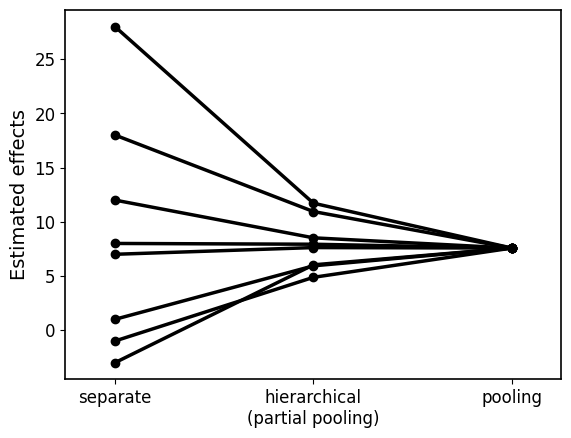

In [20]:
for i in range(8):
    plt.plot(
        [
            y[i], 
            post_thetas[..., i].mean(), 
            trace_p.posterior["theta"].values.mean()
        ],
        "-o",
        c="k",
    )

plt.xticks([0, 1, 2], ["separate", "hierarchical\n(partial pooling)", "pooling"])
plt.xlim(-0.25, 2.25)

plt.ylabel("Estimated effects")

plt.show()